# Knowledge Graph & Network Analysis of S&P 500 Earnings Calls (2024)

- Load and preprocess the **S&P 500 earnings transcripts** dataset from Hugging Face  
- Transform structured transcripts into a **segment-level DataFrame**  
- Aggregate per-company text and extract **topics using TF–IDF** (English + Danish)  
- Build a **bipartite knowledge graph** between companies and topics using NetworkX  
- Perform **network analysis** (degree & betweenness centrality, optional communities)  
- Create **visualisations** (bar charts & ego network) for interpretation

### conclusions:
the **most central topics** as key concerns across the S&P 500.
- Compare specific companies (e.g. PayPal vs. other financial firms).
- Discuss how this graph-based view complements more traditional text analysis
  (e.g. simple word frequencies or sentiment).


## 1. Imports

In [52]:
from datasets import load_dataset
import pandas as pd
import numpy as np
import json

import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer
import networkx as nx
import plotly.graph_objects as go


## 2. Load Hugging Face Dataset

We use the public dataset: `kurry/sp500_earnings_transcripts`.

Each record corresponds to one earnings call transcript and contains a field
`structured_content`, which is itself a list of speaker turns.


In [53]:
# Load the S&P 500 earnings transcripts dataset
ds = load_dataset("kurry/sp500_earnings_transcripts", split="train")

print("Number of transcripts:", len(ds))

# Inspect a sample record
rec = ds[0]
print(rec["symbol"], rec["company_name"], rec["date"], "Q"+str(rec["quarter"]), rec["year"])
for seg in rec["structured_content"][:5]:
    print(seg["speaker"], ":", seg["text"][:80], "…")

Number of transcripts: 33362
A Agilent Technologies, Inc. 2020-11-23 16:30:00 Q4 2020
Operator : Good afternoon, and welcome to the Agilent Technologies Fourth Quarter Earnings  …
Ankur Dhingra : Thank you, and welcome everyone to Agilent's fourth quarter and full-year confer …
Mike McMullen : Thanks, Ankur, and thanks to everyone for joining us on our call today. Today, I …
Bob McMahon : Thanks, Mike, and good afternoon, everyone. In my remarks today, I'll provide so …
Ankur Dhingra : Thanks, Bob. David, let's provide the instructions for Q&A. …


## 3. Flatten Structured Content into a Segment-Level DataFrame

The column `structured_content` is a list of segments (speaker + text) per transcript.

We convert this into a long-form DataFrame **`utterances`**, with one row per segment:

- `transcript_id` – index of the transcript in the dataset  
- `symbol`, `company_name`, `date`, `quarter`, `year` – metadata  
- `seg_id` – index of the segment within the transcript  
- `speaker` – speaker label (e.g. operator, CEO, analyst)  
- `text` – raw text of the utterance  
- `len_chars` – length of the text (for quick inspection)


In [54]:
rows = []
for t_id, rec in enumerate(ds):
    meta = {
        "transcript_id": t_id,
        "symbol": rec["symbol"],
        "company_name": rec["company_name"],
        "date": rec["date"],
        "quarter": rec["quarter"],
        "year": rec["year"],
    }
    for seg_id, seg in enumerate(rec["structured_content"]):
        rows.append({
            **meta,
            "seg_id": seg_id,
            "speaker": seg["speaker"],
            "text": seg["text"],
            "len_chars": len(seg["text"]),
        })

utterances = pd.DataFrame(rows)
utterances.head()

,transcript_id,symbol,company_name,date,quarter,year,seg_id,speaker,text,len_chars
0,0,A,"Agilent Technologies, Inc.",2020-11-23 16:30:00,4,2020,0,Operator,"Good afternoon, and welcome to the Agilent Tec...",419
1,0,A,"Agilent Technologies, Inc.",2020-11-23 16:30:00,4,2020,1,Ankur Dhingra,"Thank you, and welcome everyone to Agilent's f...",1877
2,0,A,"Agilent Technologies, Inc.",2020-11-23 16:30:00,4,2020,2,Mike McMullen,"Thanks, Ankur, and thanks to everyone for join...",6890
3,0,A,"Agilent Technologies, Inc.",2020-11-23 16:30:00,4,2020,3,Bob McMahon,"Thanks, Mike, and good afternoon, everyone. In...",7245
4,0,A,"Agilent Technologies, Inc.",2020-11-23 16:30:00,4,2020,4,Ankur Dhingra,"Thanks, Bob. David, let's provide the instruct...",59


## 5. Filter to a Single Year (2024)

To keep the analysis focused and computationally manageable, we restrict
the network to **utterances from 2024**.


In [55]:
d = utterances[utterances["year"] == 2024].copy()
d["date"] = pd.to_datetime(d["date"])

print("Rows in 2024:", len(d))
print("Unique companies in 2024:", d["company_name"].nunique())

Rows in 2024: 138105
Unique companies in 2024: 493


## 6. Aggregate to Company-Level Documents

For topic extraction, we combine all utterances per company into a single
document. Each document represents **how that company communicated in 2024**.

We compute:

- `full_text` – concatenated text per (symbol, company_name)
- `first_year`, `last_year` – useful if you later want multi-year slices


In [56]:
company_docs = (
    d.groupby(["symbol", "company_name"], as_index=False)
      .agg(
          full_text=("text", lambda x: " ".join(x.astype(str))),
          first_year=("year", "min"),
          last_year=("year", "max"),
      )
)

print("Number of company documents:", len(company_docs))
company_docs.head()

Number of company documents: 493


,symbol,company_name,full_text,first_year,last_year
0,A,"Agilent Technologies, Inc.","Good afternoon. My name is Rob, and I will be ...",2024,2024
1,AAPL,Apple Inc.,"Good afternoon, and welcome to the Apple Q4 Fi...",2024,2024
2,ABBV,AbbVie Inc.,Good morning and thank you for standing by. We...,2024,2024
3,ABNB,"Airbnb, Inc.","Good afternoon, and thank you for joining Airb...",2024,2024
4,ABT,Abbott Laboratories,Good morning and thank you for standing by. We...,2024,2024


## 7. Topic Extraction via TF–IDF

We use `TfidfVectorizer` to extract the most characteristic unigrams and bigrams
for each company document.

Special points:

- We choose `min_df` and `max_df` values that are robust to small numbers of documents.


In [57]:
# Build combined English + Danish stopword list

def get_english_stopwords():
    """Creates a robust list of English stopwords."""
    try:
        # Start with the standard list from sklearn
        from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS as sklearn_sw
        base = set(sklearn_sw)
    except ImportError:
        # Fallback to a basic list if sklearn is not available
        base = {"a", "an", "and", "the", "in", "is", "it", "of", "for", "on", "with", "as", "by", "that", "this"}

    # Add custom stopwords common in forum/reddit data
    custom_stopwords = {
        "im", "ive", "id", "like", "just", "dont", "know", "feel", "think",
        "people", "really", "want", "time", "would", "get", "one", "even", "go", "going",
        "said", "say", "make", "something", "anything", "everything",
        "reddit", "post", "thread", "comment", "subreddit", "op", "aita", "tldr",
        "edit", "update", "hey", "hi", "hello", "thanks", "thank", "please", "plz", "lol"
    }
    base.update(custom_stopwords)

    return sorted(list(base))

ENGLISH_STOPWORDS = get_english_stopwords()
n_docs = len(ENGLISH_STOPWORDS)



min_df = 2
max_df = 0.9    # at most 90%

print(f"Using min_df={min_df}, max_df={max_df} with {n_docs} documents.")

vectorizer = TfidfVectorizer(
    stop_words=list(ENGLISH_STOPWORDS),
    ngram_range=(1, 2),
    max_features=5000,
    min_df=min_df,
    max_df=max_df,
)

X = vectorizer.fit_transform(company_docs["full_text"])
terms = np.array(vectorizer.get_feature_names_out())

print("TF-IDF matrix shape:", X.shape)  # (num_companies, num_terms)

Using min_df=2, max_df=0.9 with 352 documents.
TF-IDF matrix shape: (493, 5000)


## 8. Build Company–Topic Edge List

We now construct an **edge list** where:

- Each row is a (company, topic) pair
- `weight_tfidf` is the TF–IDF score of that term for that company
- We keep the top `K` topics per company

This edge list is the basis for our knowledge graph.


In [58]:
TOP_K = 30  # number of topics per company to keep

edge_rows = []
for i in range(X.shape[0]):  # loop over companies
    row = X.getrow(i).toarray().ravel()
    if row.sum() == 0:
        continue

    # indices of top K terms by TF–IDF
    top_idx = row.argsort()[::-1][:TOP_K]
    top_scores = row[top_idx]

    # Ignore zero scores in case of sparse rows
    mask = top_scores > 0
    top_idx = top_idx[mask]
    top_scores = top_scores[mask]

    symbol = company_docs.loc[i, "symbol"]
    company_name = company_docs.loc[i, "company_name"]
    first_year = int(company_docs.loc[i, "first_year"])
    last_year = int(company_docs.loc[i, "last_year"])

    for term_idx, score in zip(top_idx, top_scores):
        topic = terms[term_idx]
        edge_rows.append({
            "symbol": symbol,
            "company_name": company_name,
            "topic": topic,
            "weight_tfidf": float(score),
            "first_year": first_year,
            "last_year": last_year,
        })



In [59]:
# list all topic in the edge rows and calculate the frequency
all_topics = [row['topic'] for row in edge_rows]
topic_counts = pd.Series(all_topics).value_counts()
print("Top 10 most common topics across companies:")
print(topic_counts.head(10))

# all unique topics
unique_topics = topic_counts.index.tolist()
print(unique_topics)

Top 10 most common topics across companies:
morning         181
good morning    139
adjusted        100
slide            97
fiscal           95
ebitda           81
comes line       81
ai               78
gross            74
consumer         68
Name: count, dtype: int64
['morning', 'good morning', 'adjusted', 'slide', 'fiscal', 'ebitda', 'comes line', 'ai', 'gross', 'consumer', 'organic', 'china', 'basis points', 'segment', 'gross margin', 'clients', 'cash flow', 'inventory', 'solutions', 'gas', 'client', 'services', 'income', 'international', 'energy', 'fiscal year', 'brands', 'line open', 'brand', 'supply', 'adjusted ebitda', 'industrial', 'currency', 'backlog', 'free cash', 'capacity', 'software', 'production', 'john', 'proceed', 'data center', 'store', 'cloud', 'projects', 'north america', 'commercial', 'assets', 'patients', 'north', 'profit', 'europe', 'yeah', 'bookings', 'global', 'digital', 'credit', 'businesses', 'property', 'constant currency', 'volumes', 'digit', 'productivity

we can see it make sense that morning, good morning, adjusted, slide is the most common topic across companies, as these are common phrases used in earnings calls.

So what we should do is to filter out these common topics that are not meaningful for our analysis.
keep topic only is business related, such as revenue, profit, growth, Ai, engeneering, product, market, customer, etc.

In [60]:
# Financial performance & P&L
meaningful_topics = [
    # core P&L
    "revenue", "revenues", "revenue growth", "revenue increased",
    "revenue billion", "total revenue", "total revenues", "revenue per",
    "sales", "net sales", "sales growth", "sales increased", "sales billion",
    "earnings", "earnings growth", "earnings per",
    "adjusted earnings", "gaap earnings", "gaap eps", "gaap net",
    "gross", "gross margin", "gross margins", "gross profit", "adjusted gross",
    "operating income", "operating profit", "operating earnings",
    "operating margin", "operating margins", "margin expansion",
    "margin performance", "profit", "profit margin", "profitability", "profits",
    "ebit", "ebitda", "adjusted ebitda", "ebitda margin", "ebitda margins",
    "eps", "adjusted eps", "diluted eps", "diluted earnings",
    "adjusted net", "adjusted basis",
    # cash & returns
    "cash flow", "cash flows", "free cash", "free cash flow",
    "cash generation", "flow growth", "flow conversion",
    "net income", "net earnings", "net revenue",
    "ffo", "affo", "roe", "roi",
]

In [61]:
#Balance sheet, capital, rates, risk
meaningful_topics += [
    "debt", "leverage",
    "capital", "capital plan", "capital spending", "capital investment",
    "capital investments", "capital deployment", "capital allocation",
    "capital expenditures",
    "working capital", "balance sheet",

    "liquidity",
    "interest rate", "interest rates", "interest income", "interest bearing",
    "fixed income",

    "inflation",
    "risk management", "risk adjusted",
    "regulation", "regulatory",
    "volatility",
    "loss", "losses", "loss ratio",
]


In [62]:
#Banking, credit & payments
meaningful_topics += [
    "bank", "banking",
    "loans", "loan", "loan growth", "mortgage",
    "deposits", "deposit", "net interest",
    "charge offs", "net charge", "charge",
    "cet1",
    "credit", "credit card",
    "capital markets", "trading",
    "securities", "equity", "equities",
    "fund", "funds", "etf", "etfs", "aum",
    "private credit", "private equity",
    "service revenue", "non interest",
    "payments", "payment", "transaction", "transactional",
]


In [63]:
#Demand, customers, markets
meaningful_topics += [
    # customers & demand
    "consumer", "consumers", "consumer demand",
    "customer", "customers", "customer service", "customer experience",
    "client", "clients", "client base",
    "churn", "retention",
    "traffic", "volume growth", "volumes",

    # market / macro
    "market", "market share", "market conditions", "market environment",
    "market dynamics", "market growth",
    "macroeconomic", "economy", "economic",
    "demand growth", "demand environment",
]


In [64]:
#Pricing, costs, efficiency, supply chain
meaningful_topics += [
    "pricing", "pricing power", "pricing actions",
    "price", "prices", "price mix", "price cost", "price increase",
    "cost", "cost per", "cost savings", "cost capital",
    "expenses", "expense ratio", "expense growth",
    "opex", "capex", "operating expense", "operating expenses",

    "efficiency", "efficiencies", "productivity",
    "optimization", "operational excellence",
    "utilization",

    "inventory", "inventory levels", "inventories",
    "supply", "supply chain", "supply demand",
    "distribution", "logistics",
    "backlog", "orders", "order", "bookings", "book bill", "targets",
]


In [65]:
#Technology, software, AI, infra
meaningful_topics += [
    "ai", "artificial intelligence", "gen ai", "generative ai",
    "cloud", "data center", "data centers",
    "software", "saas", "platform", "platforms",
    "compute", "compute", "server", "servers", "gpu", "gpus",
    "semiconductor", "foundry", "chip", "chips", "memory", "hbm", "dram",
    "network", "networking",
    "cyber", "cybersecurity",
    "automation", "robotics",
    "models", "engineering",
    "digital", "online", "streaming", "workloads", "workflows",
    "use cases", "analytics",
]


In [66]:
#energy, utilities, industrial
meaningful_topics += [
    "energy", "energy transition", "clean energy",
    "oil", "gas", "natural gas", "oil gas",
    "lng", "gulf coast", "barrels", "crude",

    "utility", "utilities", "grid",
    "power", "power generation",
    "megawatt", "megawatts", "gigawatts",

    "industrial", "capacity", "production",
    "midstream", "upstream", "rig", "rigs",

    "aerospace", "aircraft",
    "manufacturing", "factory", "factories",
    "infrastructure",
]


In [67]:
# real estate & REITs
meaningful_topics += [
    "real estate",
    "rent", "rents", "rent growth",
    "lease", "leases", "leasing", "new lease",
    "occupancy",
    "ffo", "noi",
    "revpar",
    "multifamily", "single family", "residential", "commercial real",
    "properties", "property",
    "tenant", "tenants",
]


In [68]:
#healthcare, pharma, life sciences
meaningful_topics += [
    "health", "healthcare", "health care",
    "medical", "medicare", "medicaid",
    "pharma", "pharmaceutical", "medicines",
    "oncology", "disease", "therapy", "therapies",
    "patient", "patients",
    "clinical", "trials", "trial", "diagnostics", "diagnostic",
    "life sciences", "life science",
    "biotech",
]


In [69]:
#retail, consumer, commerce
meaningful_topics += [
    "retail", "retail sales", "retailer", "retailers",
    "store", "stores", "store sales", "same store",
    "grocery", "snacks", "beverage", "food",
    "merchandise", "merchandising",
    "e-commerce", "commerce", "marketplace",
    "advertising", "marketing", "categories", "category",
    "loyalty",
    "apparel", "luxury",
    "restaurant", "restaurants", "hotel", "hotels",
    "travel", "travelers",
]


In [70]:
#transport, industry, misc.
meaningful_topics += [
    "transportation", "shipping", "freight", "truck", "trucks",
    "vehicles", "vehicle", "auto", "automotive",
    "ev", "evs",
    "ports", "port", "throughput",
    "aerospace", "aviation",
    "infrastructure", "construction", "equipment", "hvac",
    "manufacturing", "midstream", "offshore",
]


In [71]:
#Growth strategy, recurring, business model
meaningful_topics += [
    "organic growth", "organic revenue", "organic sales", "organic net",
    "growth", "growth strategy", "growth investments", "high growth",
    "profitable growth", "growth initiatives",
    "subscription", "subscriptions", "recurring", "recurring revenue",
    "service revenue", "products services", "new products", "product mix",
    "product launches", "new business", "new customers", "new customer",
    "base business", "installed base",
]


In [72]:
# countries
meaningful_topics += ["China", "India", "Brazil", "Russia", "Germany", "France", "UK", "United Kingdom", "Italy", "Spain","EU","Europe",
                      "Denmark", "Sweden", "Norway", "Finland", "Nordics",
                      "USA", "United States", "America", "Canada", "Mexico", "South America",
                      "Australia", "New Zealand","Japan","South Korea","Korea","Singapore","Malaysia","Indonesia","Philippines","Thailand","Vietnam"]

In [73]:
MEANINGFUL_TOPICS = set(meaningful_topics)

In [74]:
# keep only meaningful topics in the edge rows
edge_rows = [row for row in edge_rows if row['topic'] in meaningful_topics]
edges = pd.DataFrame(edge_rows)
print("Raw company–topic edges:", len(edges))

# Compress duplicates as a safety measure (e.g. if you later merge slices)
edges = (
    edges
    .groupby(["symbol", "company_name", "topic"], as_index=False)
    .agg(
        weight_tfidf=("weight_tfidf", "mean"),
        first_year=("first_year", "min"),
        last_year=("last_year", "max"),
    )
)

print("Unique company–topic edges:", len(edges))
edges.head()

Raw company–topic edges: 4244
Unique company–topic edges: 4244


,symbol,company_name,topic,weight_tfidf,first_year,last_year
0,A,"Agilent Technologies, Inc.",clinical,0.119317,2024,2024
1,A,"Agilent Technologies, Inc.",diagnostics,0.093923,2024,2024
2,A,"Agilent Technologies, Inc.",orders,0.098689,2024,2024
3,A,"Agilent Technologies, Inc.",pharma,0.321584,2024,2024
4,AAPL,Apple Inc.,ai,0.072340,2024,2024


## 9. Build Bipartite Knowledge Graph with NetworkX

We now create a **bipartite graph**:

- Company nodes (type = `"company"`, id = ticker symbol)
- Topic nodes (type = `"topic"`)
- Edges: `(company_symbol, topic)` with `weight = TF–IDF score`

This graph is our *knowledge graph* of the 2024 earnings-call discourse.


In [75]:
G = nx.Graph()

# Add company nodes with attributes
for _, row in company_docs.iterrows():
    G.add_node(
        row["symbol"],
        label=row["company_name"],
        type="company",
        first_year=int(row["first_year"]),
        last_year=int(row["last_year"]),
    )

# Add topic nodes
for topic in edges["topic"].unique():
    G.add_node(topic, type="topic")

# Add edges with attributes
for _, row in edges.iterrows():
    company_id = row["symbol"]
    topic = row["topic"]
    G.add_edge(
        company_id,
        topic,
        weight=row["weight_tfidf"],
        first_year=row["first_year"],
        last_year=row["last_year"],
    )

print("Graph:", G.number_of_nodes(), "nodes,", G.number_of_edges(), "edges")

Graph: 834 nodes, 4244 edges


In [76]:
import plotly.graph_objects as go

# -----------------------------
# Build a smaller subgraph H
# -----------------------------

# All company nodes in the big graph G
company_nodes = [n for n, d in G.nodes(data=True) if d.get("type") == "company"]

# Use degree to pick the most "connected" companies
deg_full = dict(G.degree(company_nodes))

N = 12  # number of companies to display (tune this)
top_companies = sorted(company_nodes, key=lambda n: deg_full[n], reverse=True)[:N]

# Include all topics attached to these companies
sub_nodes = set(top_companies)
for c in top_companies:
    sub_nodes.update(G.neighbors(c))

H = G.subgraph(sub_nodes).copy()
print("Interactive subgraph:", H.number_of_nodes(), "nodes,", H.number_of_edges(), "edges")

# -----------------------------
# Create a bipartite-style layout
#   - Companies on x=0
#   - Topics on x=1
# -----------------------------
companies_sub = [n for n, d in H.nodes(data=True) if d.get("type") == "company"]
topics_sub    = [n for n, d in H.nodes(data=True) if d.get("type") == "topic"]

pos = {}

# How many nodes on each side
n_topics = len(topics_sub)
n_companies = len(companies_sub)

# We'll use the company side to define the vertical span
max_y = max(n_companies - 1, 1)

# Spread topics evenly across [0, max_y]
topic_y_values = np.linspace(0, max_y, num=n_topics) if n_topics > 1 else [max_y / 2]

for y, n in zip(topic_y_values, sorted(topics_sub)):
    pos[n] = (1, y)

# Companies still stacked 0..max_y
for i, n in enumerate(sorted(companies_sub)):
    pos[n] = (0, i)


# -----------------------------
# Build edge trace
# -----------------------------
edge_x = []
edge_y = []
edge_hover_x = []
edge_hover_y = []
edge_hover_text = []

for u, v, d in H.edges(data=True):
    x0, y0 = pos[u]
    x1, y1 = pos[v]

    # edge line
    edge_x += [x0, x1, None]
    edge_y += [y0, y1, None]

    # midpoint for hover marker
    mx, my = (x0 + x1) / 2, (y0 + y1) / 2
    edge_hover_x.append(mx)
    edge_hover_y.append(my)
    edge_hover_text.append(
        f"<b>{G.nodes[u].get('label', u) if G.nodes[u].get('type')=='company' else u}</b> "
        f"↔ "
        f"<b>{G.nodes[v].get('label', v) if G.nodes[v].get('type')=='company' else v}</b><br>"
        f"TF-IDF weight: {d.get('weight', 0):.4f}"
    )

edge_trace = go.Scatter(
    x=edge_x,
    y=edge_y,
    mode="lines",
    line=dict(width=0.5, color="#888"),
    hoverinfo="none",
    name="Edges"
)

edge_hover_trace = go.Scatter(
    x=edge_hover_x,
    y=edge_hover_y,
    mode="markers",
    hoverinfo="text",
    marker=dict(size=6, color="rgba(0,0,0,0)"),  # invisible markers used only for hover
    text=edge_hover_text,
    name="Edge info"
)

# -----------------------------
# Build node trace
# -----------------------------
node_x = []
node_y = []
node_text = []
node_color = []
node_size = []

for n, d in H.nodes(data=True):
    x, y = pos[n]
    node_x.append(x)
    node_y.append(y)

    if d.get("type") == "company":
        label = d.get("label", n)
        node_text.append(f"<b>{label}</b><br>Symbol: {n}")
        node_color.append("lightblue")
        node_size.append(18)
    else:
        node_text.append(f"Topic: {n}")
        node_color.append("lightgreen")
        node_size.append(12)

node_trace = go.Scatter(
    x=node_x,
    y=node_y,
    mode="markers",
    hoverinfo="text",
    text=node_text,
    marker=dict(
        size=node_size,
        color=node_color,
        line_width=1,
        line_color="#333"
    ),
    name="Nodes"
)

# -----------------------------
# Build and show figure
# -----------------------------
fig = go.Figure(
    data=[edge_trace, edge_hover_trace, node_trace],
    layout=go.Layout(
        title="Interactive Knowledge Graph (Companies ↔ Topics, Sample)",
        title_x=0.5,
        showlegend=False,
        hovermode="closest",
        margin=dict(b=20, l=40, r=40, t=60),
        xaxis=dict(showgrid=False, zeroline=False, showticklabels=False),
        yaxis=dict(showgrid=False, zeroline=False, showticklabels=False),
    )
)

fig.show()


Interactive subgraph: 130 nodes, 190 edges


### reverse bipartite: Top K Topics + their Companies

In [77]:

# ---------------------------------
# 1) Pick top K topics in the bipartite graph
# ---------------------------------
topic_nodes = [n for n, d in G.nodes(data=True) if d.get("type") == "topic"]

# Use degree (number of companies linked to the topic) as importance
topic_deg = dict(G.degree(topic_nodes))

K = 5  # number of topics you want to focus on
top_topics = sorted(topic_nodes, key=lambda n: topic_deg[n], reverse=True)[:K]

print("Top topics:", top_topics)

# ---------------------------------
# 2) Build subgraph H: selected topics + all their companies
# ---------------------------------
sub_nodes = set(top_topics)
for t in top_topics:
    sub_nodes.update(G.neighbors(t))

H = G.subgraph(sub_nodes).copy()
print("Subgraph:", H.number_of_nodes(), "nodes,", H.number_of_edges(), "edges")

topics_sub    = [n for n, d in H.nodes(data=True) if d.get("type") == "topic"]
companies_sub = [n for n, d in H.nodes(data=True) if d.get("type") == "company"]

# ---------------------------------
# 3) Simple bipartite layout:
#    topics on the left (x=0), companies on the right (x=1)
# ---------------------------------
pos = {}

# How many nodes on each side
n_topics = len(topics_sub)
n_companies = len(companies_sub)

# We'll use the company side to define the vertical span
max_y = max(n_companies - 1, 1)

# Spread topics evenly across [0, max_y]
topic_y_values = np.linspace(0, max_y, num=n_topics) if n_topics > 1 else [max_y / 2]

for y, n in zip(topic_y_values, sorted(topics_sub)):
    pos[n] = (0, y)

# Companies still stacked 0..max_y
for i, n in enumerate(sorted(companies_sub)):
    pos[n] = (1, i)

# ---------------------------------
# 4) Edge traces (lines + hover markers)
# ---------------------------------
edge_x = []
edge_y = []
edge_hover_x = []
edge_hover_y = []
edge_hover_text = []

for u, v, d in H.edges(data=True):
    x0, y0 = pos[u]
    x1, y1 = pos[v]

    # line coordinates
    edge_x += [x0, x1, None]
    edge_y += [y0, y1, None]

    # midpoint for hover
    mx, my = (x0 + x1) / 2, (y0 + y1) / 2
    edge_hover_x.append(mx)
    edge_hover_y.append(my)

    # figure out which endpoint is topic / company for nicer label
    if H.nodes[u].get("type") == "topic":
        topic_name = u
        company_label = H.nodes[v].get("label", v)
        symbol = v
    else:
        topic_name = v
        company_label = H.nodes[u].get("label", u)
        symbol = u

    edge_hover_text.append(
        f"<b>{topic_name}</b><br>"
        f"Company: <b>{company_label}</b> ({symbol})<br>"
        f"TF-IDF weight: {d.get('weight', 0):.4f}"
    )

edge_trace = go.Scatter(
    x=edge_x,
    y=edge_y,
    mode="lines",
    line=dict(width=0.5, color="#888"),
    hoverinfo="none",
    name="Edges"
)

edge_hover_trace = go.Scatter(
    x=edge_hover_x,
    y=edge_hover_y,
    mode="markers",
    hoverinfo="text",
    marker=dict(size=6, color="rgba(0,0,0,0)"),  # invisible; used only for hover
    text=edge_hover_text,
    name="Edge info"
)

# ---------------------------------
# 5) Node trace (topics vs companies)
# ---------------------------------
node_x = []
node_y = []
node_text = []
node_color = []
node_size = []

for n, d in H.nodes(data=True):
    x, y = pos[n]
    node_x.append(x)
    node_y.append(y)

    if d.get("type") == "topic":
        node_text.append(f"<b>Topic:</b> {n}<br>Degree: {topic_deg.get(n, 0)}")
        node_color.append("lightgreen")
        node_size.append(20)  # make topics big
    else:
        label = d.get("label", n)
        node_text.append(f"<b>{label}</b><br>Symbol: {n}")
        node_color.append("lightblue")
        node_size.append(14)

node_trace = go.Scatter(
    x=node_x,
    y=node_y,
    mode="markers",
    hoverinfo="text",
    text=node_text,
    marker=dict(
        size=node_size,
        color=node_color,
        line_width=1,
        line_color="#333"
    ),
    name="Nodes"
)

# ---------------------------------
# 6) Final interactive figure
# ---------------------------------
fig = go.Figure(
    data=[edge_trace, edge_hover_trace, node_trace],
    layout=go.Layout(
        title=f"Interactive Knowledge Graph: Top {K} Topics ↔ Companies (2024)",
        title_x=0.5,
        showlegend=False,
        hovermode="closest",
        margin=dict(b=20, l=40, r=40, t=60),
        xaxis=dict(showgrid=False, zeroline=False, showticklabels=False),
        yaxis=dict(showgrid=False, zeroline=False, showticklabels=False),
    )
)

fig.show()

Top topics: ['ebitda', 'ai', 'gross', 'consumer', 'gross margin']
Subgraph: 249 nodes, 364 edges


## 10. Network Analysis – Centrality Measures

To understand the *importance* of nodes in the knowledge graph, we compute:

- **Degree centrality** – how many neighbors a node has (normalized)
- **Betweenness centrality** – how often a node lies on shortest paths

We compute these for both companies and topics.


In [78]:
# Degree centrality
deg_centrality = nx.degree_centrality(G)

# Betweenness centrality (weighted)
bet_centrality = nx.betweenness_centrality(G, weight="weight")

centrality_df = pd.DataFrame([
    {
        "node": n,
        "type": G.nodes[n].get("type", "unknown"),
        "label": G.nodes[n].get("label", n) if G.nodes[n].get("type") == "company" else n,
        "degree_centrality": deg_centrality[n],
        "betweenness_centrality": bet_centrality[n],
        "community": None,  # will be filled if we run Louvain
    }
    for n in G.nodes()
])

centrality_df.head()

,node,type,label,degree_centrality,betweenness_centrality,community
0,A,company,"Agilent Technologies, Inc.",0.004802,0.000118,None
1,AAPL,company,Apple Inc.,0.004802,0.000866,None
2,ABBV,company,AbbVie Inc.,0.009604,0.001068,None
3,ABNB,company,"Airbnb, Inc.",0.009604,0.014140,None
4,ABT,company,Abbott Laboratories,0.012005,0.001007,None


### 10.1 Inspect Top Central Companies and Topics

In [79]:
top_companies_by_deg = (
    centrality_df[centrality_df["type"] == "company"]
    .sort_values("degree_centrality", ascending=False)
    .head(10)
)

top_topics_by_deg = (
    centrality_df[centrality_df["type"] == "topic"]
    .sort_values("degree_centrality", ascending=False)
    .head(10)
)

print("Top 10 companies by degree centrality:")
print(top_companies_by_deg[["node", "label", "degree_centrality"]])

print("\nTop 10 topics by degree centrality:")
print(top_topics_by_deg[["node", "degree_centrality"]])

Top 10 companies by degree centrality:
     node                                        label  degree_centrality
61    BKR                         Baker Hughes Company           0.021609
196   GEV                              GE Vernova Inc.           0.020408
160  EQIX                                Equinix, Inc.           0.020408
107   CPT                        Camden Property Trust           0.019208
91    CLX                           The Clorox Company           0.019208
405   SPG                   Simon Property Group, Inc.           0.019208
228   IBM  International Business Machines Corporation           0.019208
339     O                    Realty Income Corporation           0.018007
287   MAA      Mid-America Apartment Communities, Inc.           0.018007
476   WFC                        Wells Fargo & Company           0.018007

Top 10 topics by degree centrality:
             node  degree_centrality
577        ebitda           0.097239
497            ai           0.093637

## 11. (Optional) Community Detection with Louvain

Community detection helps identify **clusters** of tightly connected nodes,
which often correspond to:

- Groups of companies discussing similar topics
- Groups of topics that co-occur with similar companies

Here we use the Louvain method (if available).


## 12. Visualisations – Top Nodes by Degree Centrality

We now create bar charts to visualise the most central companies and topics.
These plots are easy to interpret in a report.


### 12.1 Top 15 companies by degree centrality

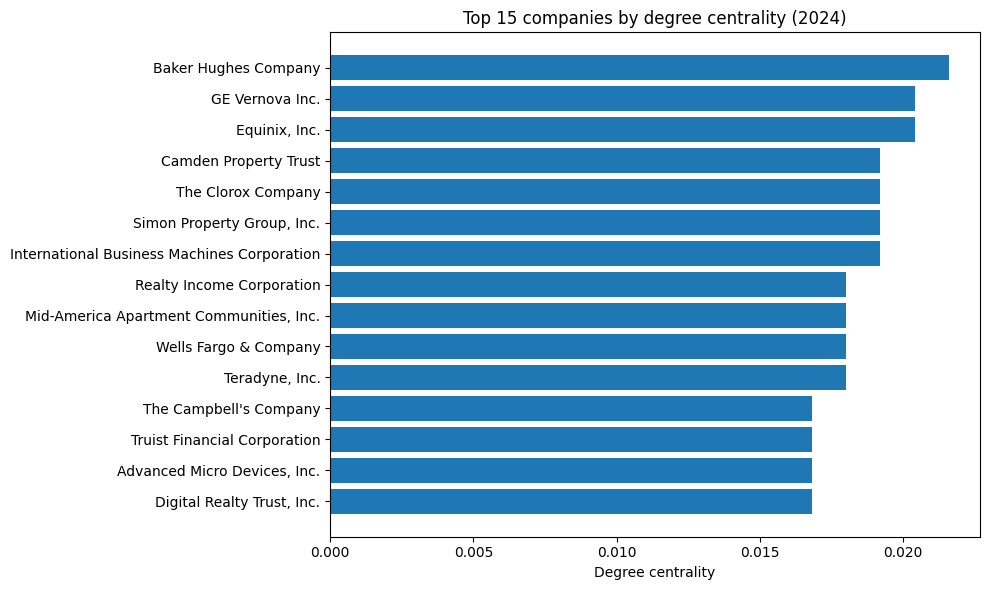

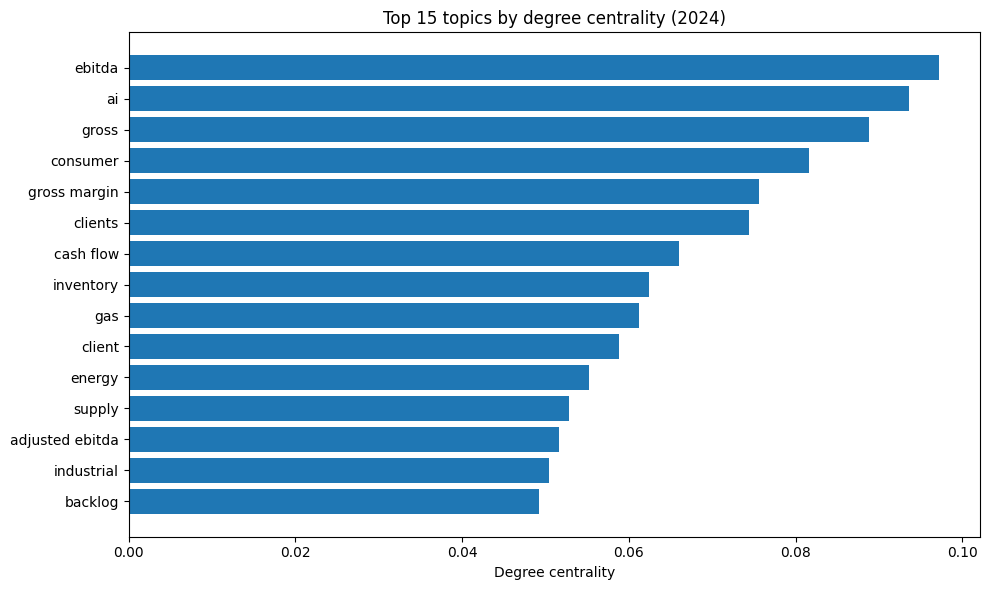

In [80]:
# Top 15 companies by degree centrality
top_companies = (
    centrality_df[centrality_df["type"] == "company"]
    .sort_values("degree_centrality", ascending=False)
    .head(15)
)

plt.figure(figsize=(10, 6))
plt.barh(top_companies["label"], top_companies["degree_centrality"])
plt.gca().invert_yaxis()
plt.xlabel("Degree centrality")
plt.title("Top 15 companies by degree centrality (2024)")
plt.tight_layout()
plt.show()

# Top 15 topics by degree centrality
top_topics = (
    centrality_df[centrality_df["type"] == "topic"]
    .sort_values("degree_centrality", ascending=False)
    .head(15)
)

plt.figure(figsize=(10, 6))
plt.barh(top_topics["node"], top_topics["degree_centrality"])
plt.gca().invert_yaxis()
plt.xlabel("Degree centrality")
plt.title("Top 15 topics by degree centrality (2024)")
plt.tight_layout()
plt.show()

In [81]:
company_nodes = [n for n, d in G.nodes(data=True) if d.get("type") == "company"]

len(company_nodes), company_nodes[:10]
import itertools

# Company–company graph weighted by TF-IDF similarity
G_company_tfidf = nx.Graph()

for c1, c2 in itertools.combinations(company_nodes, 2):
    # Topics connected to each company
    t1 = set(G.neighbors(c1))
    t2 = set(G.neighbors(c2))
    shared_topics = t1 & t2

    if not shared_topics:
        continue

    # Similarity weight = sum of min(TF-IDF) on shared topics
    weight = 0.0
    for topic in shared_topics:
        w1 = G[c1][topic]["weight"]
        w2 = G[c2][topic]["weight"]
        weight += min(w1, w2)

    if weight > 0:
        G_company_tfidf.add_edge(c1, c2, weight=weight)

print("Company–company TF-IDF graph:",
      G_company_tfidf.number_of_nodes(), "nodes,",
      G_company_tfidf.number_of_edges(), "edges")
deg_cc = nx.degree_centrality(G_company_tfidf)
bet_cc = nx.betweenness_centrality(G_company_tfidf, weight="weight")

company_similarity_df = pd.DataFrame([
    {
        "symbol": n,
        "label": G.nodes[n]["label"],    # company name
        "degree": deg_cc[n],
        "betweenness": bet_cc[n],
    }
    for n in G_company_tfidf.nodes()
])

company_similarity_df.sort_values("degree", ascending=False).head(10)


Company–company TF-IDF graph: 493 nodes, 34330 edges


,symbol,label,degree,betweenness
113,EXPE,"Expedia Group, Inc.",0.583333,0.004919
112,EQIX,"Equinix, Inc.",0.577236,0.001852
73,ADI,"Analog Devices, Inc.",0.567073,0.000191
68,ZBRA,Zebra Technologies Corporation,0.554878,0.000520
158,OMC,Omnicom Group Inc.,0.544715,0.002481
38,IQV,IQVIA Holdings Inc.,0.536585,0.002812
129,IBM,International Business Machines Corporation,0.532520,0.006276
109,EFX,Equifax Inc.,0.530488,0.004742
179,SWK,"Stanley Black & Decker, Inc.",0.524390,0.000613
132,IPG,"The Interpublic Group of Companies, Inc.",0.518293,0.004017


In [82]:

# You can also use a percentile instead of a fixed number.
weights = [d["weight"] for _, _, d in G_company_tfidf.edges(data=True)]
if len(weights) == 0:
    print("No company-company edges were created (maybe very few shared topics).")
else:
    thresh = np.percentile(weights, 90)  # top 10% strongest edges
    print("Using threshold:", thresh)

    H_cc = nx.Graph([
        (u, v, d) for u, v, d in G_company_tfidf.edges(data=True)
        if d["weight"] >= thresh
    ])

    print("Subgraph for plotting:", H_cc.number_of_nodes(), "nodes,",
          H_cc.number_of_edges(), "edges")


Using threshold: 0.31756175729104297
Subgraph for plotting: 447 nodes, 3433 edges


### 12.2 Company–Company Similarity Network (Top Similarity Edges, 2024)

In [83]:

if H_cc.number_of_nodes() > 0:
    # Layout positions from NetworkX
    pos = nx.spring_layout(H_cc, seed=42, k=0.4)

    # --- Build edge traces ---
    edge_x = []
    edge_y = []
    edge_weights = []
    edge_text = []

    for u, v, d in H_cc.edges(data=True):
        x0, y0 = pos[u]
        x1, y1 = pos[v]
        edge_x += [x0, x1, None]
        edge_y += [y0, y1, None]
        edge_weights.append(d["weight"])
        edge_text.append(f"{G.nodes[u]['label']} ↔ {G.nodes[v]['label']}<br>weight={d['weight']:.4f}")

    edge_trace = go.Scatter(
        x=edge_x,
        y=edge_y,
        line=dict(width=0.5, color="#888"),
        hoverinfo="none",
        mode="lines",
        name="Similarity"
    )

    # Optional: separate edge hover markers at midpoints
    edge_mid_x = []
    edge_mid_y = []
    for u, v, d in H_cc.edges(data=True):
        x0, y0 = pos[u]
        x1, y1 = pos[v]
        edge_mid_x.append((x0 + x1) / 2)
        edge_mid_y.append((y0 + y1) / 2)

    edge_hover_trace = go.Scatter(
        x=edge_mid_x,
        y=edge_mid_y,
        mode="markers",
        hoverinfo="text",
        marker=dict(size=5, color="rgba(0,0,0,0)"),  # invisible markers
        text=edge_text,
        name="Edge info"
    )

    # --- Build node trace ---
    degrees = dict(H_cc.degree())
    max_deg = max(degrees.values()) if degrees else 1

    node_x = []
    node_y = []
    node_size = []
    node_text = []

    for n in H_cc.nodes():
        x, y = pos[n]
        node_x.append(x)
        node_y.append(y)
        # Node size scaled by degree
        node_size.append(10 + 30 * (degrees[n] / max_deg))
        label = G.nodes[n]["label"]
        node_text.append(
            f"{label}<br>symbol={n}"
            f"<br>degree={degrees[n]}"
        )

    node_trace = go.Scatter(
        x=node_x,
        y=node_y,
        mode="markers",
        hoverinfo="text",
        text=node_text,
        marker=dict(
            showscale=True,
            colorscale="Blues",
            reversescale=False,
            color=[degrees[n] for n in H_cc.nodes()],
            size=node_size,
            colorbar=dict(
                thickness=15,
                title="Degree",
                xanchor="left",

            ),
            line_width=1
        ),
        name="Companies"
    )

    fig = go.Figure(
        data=[edge_trace, edge_hover_trace, node_trace],
        layout=go.Layout(
            title="Company–Company Similarity Network (Top Similarity Edges, 2024)",
            title_x=0.5,
            showlegend=False,
            hovermode="closest",
            margin=dict(b=20, l=5, r=5, t=40),
            xaxis=dict(showgrid=False, zeroline=False, showticklabels=False),
            yaxis=dict(showgrid=False, zeroline=False, showticklabels=False),
        )
    )

    fig.show()
else:
    print("No edges in the thresholded company-company graph to plot.")


### 12.21 Build Topic–Topic Projection

In [84]:

# -----------------------------
# 1) Build Topic–Topic Projection
# -----------------------------
# Assume G is your original bipartite graph with node attribute "type" = "topic" or "company"
topics = [n for n, d in G.nodes(data=True) if d.get("type") == "topic"]
companies = [n for n, d in G.nodes(data=True) if d.get("type") == "company"]

# Weighted projection: topics connected if they share companies
topic_graph = nx.Graph()
for i, t1 in enumerate(topics):
    for t2 in topics[i+1:]:
        shared = set(G.neighbors(t1)) & set(G.neighbors(t2))
        if shared:
            topic_graph.add_edge(t1, t2, weight=len(shared))

# Optional: threshold edges
H_tt = nx.Graph(((u, v, d) for u, v, d in topic_graph.edges(data=True) if d["weight"] >= 2))

print(f"Topic–Topic graph: {H_tt.number_of_nodes()} nodes, {H_tt.number_of_edges()} edges")

# -----------------------------
# 2) Visualization Function
# -----------------------------
def plot_graph_interactive(H, title):
    if H.number_of_nodes() == 0:
        print("Graph is empty.")
        return

    pos = nx.spring_layout(H, seed=42, k=0.4)

    # Edge traces
    edge_x, edge_y, edge_text = [], [], []
    for u, v, d in H.edges(data=True):
        x0, y0 = pos[u]
        x1, y1 = pos[v]
        edge_x += [x0, x1, None]
        edge_y += [y0, y1, None]
        edge_text.append(f"{u} ↔ {v}<br>shared companies={d['weight']}")

    edge_trace = go.Scatter(
        x=edge_x, y=edge_y,
        line=dict(width=0.5, color="#888"),
        hoverinfo="none", mode="lines"
    )

    # Hover markers for edges
    edge_mid_x, edge_mid_y = [], []
    for u, v in H.edges():
        x0, y0 = pos[u]
        x1, y1 = pos[v]
        edge_mid_x.append((x0 + x1) / 2)
        edge_mid_y.append((y0 + y1) / 2)

    edge_hover_trace = go.Scatter(
        x=edge_mid_x, y=edge_mid_y,
        mode="markers", hoverinfo="text",
        marker=dict(size=5, color="rgba(0,0,0,0)"),
        text=edge_text
    )

    # Node traces
    degrees = dict(H.degree())
    max_deg = max(degrees.values()) if degrees else 1
    node_x, node_y, node_size, node_text = [], [], [], []
    for n in H.nodes():
        x, y = pos[n]
        node_x.append(x)
        node_y.append(y)
        node_size.append(10 + 30 * (degrees[n] / max_deg))
        node_text.append(f"Topic: {n}<br>Degree={degrees[n]}")

    node_trace = go.Scatter(
        x=node_x, y=node_y,
        mode="markers", hoverinfo="text",
        text=node_text,
        marker=dict(
            showscale=True,
            colorscale="Greens",
            color=[degrees[n] for n in H.nodes()],
            size=node_size,
            colorbar=dict(title="Degree"),
            line_width=1
        )
    )

    fig = go.Figure(data=[edge_trace, edge_hover_trace, node_trace],
                    layout=go.Layout(
                        title=title, title_x=0.5,
                        showlegend=False, hovermode="closest",
                        margin=dict(b=20, l=5, r=5, t=40),
                        xaxis=dict(showgrid=False, zeroline=False, showticklabels=False),
                        yaxis=dict(showgrid=False, zeroline=False, showticklabels=False)
                    ))
    fig.show()

# -----------------------------
# 3) Compare Topic–Topic vs Company–Company
# -----------------------------
# Assume H_cc is your company–company graph
metrics = {
    "Company–Company": {
        "nodes": H_cc.number_of_nodes(),
        "edges": H_cc.number_of_edges(),
        "densitynodes": H_tt.number_of_nodes(),
        "edges": H_tt.number_of_edges(),
        "density": nx.density(H_tt),
        "avg_degree": sum(dict(H_tt.degree()).values()) / H_tt.number_of_nodes()
    }
}

print("Comparison of projections:")
for name, m in metrics.items():
    print(f"{name}: nodes={m['nodes']}, edges={m['edges']}, density={m['density']:.4f}, avg_degree={m['avg_degree']:.2f}")

# -----------------------------
# 4) Visualize Topic–Topic
# -----------------------------
plot_graph_interactive(H_tt, "Topic–Topic Shared Companies Network")

Topic–Topic graph: 296 nodes, 3436 edges
Comparison of projections:
Company–Company: nodes=447, edges=3436, density=0.0787, avg_degree=23.22


In [85]:
import umap.umap_ as umap

# UMAP: from TF-IDF to 2D embedding space
umap_model = umap.UMAP(
    n_neighbors=15,
    min_dist=0.1,
    n_components=2,
    metric="cosine",
    random_state=42
)


company_embeddings = umap_model.fit_transform(X)
company_embeddings.shape


E:\Projects\NLP_exam\.venv\Lib\site-packages\umap\umap_.py:1952: UserWarning:

n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.



(493, 2)

In [86]:
company_docs["umap_x"] = company_embeddings[:, 0]
company_docs["umap_y"] = company_embeddings[:, 1]
company_docs.head()


,symbol,company_name,full_text,first_year,last_year,umap_x,umap_y
0,A,"Agilent Technologies, Inc.","Good afternoon. My name is Rob, and I will be ...",2024,2024,7.663214,3.974226
1,AAPL,Apple Inc.,"Good afternoon, and welcome to the Apple Q4 Fi...",2024,2024,4.928406,1.692437
2,ABBV,AbbVie Inc.,Good morning and thank you for standing by. We...,2024,2024,9.122008,5.399841
3,ABNB,"Airbnb, Inc.","Good afternoon, and thank you for joining Airb...",2024,2024,4.861953,3.674393
4,ABT,Abbott Laboratories,Good morning and thank you for standing by. We...,2024,2024,8.481277,4.814306


In [87]:
import hdbscan

clusterer = hdbscan.HDBSCAN(
    min_cluster_size=6,
    metric='euclidean'
).fit(company_embeddings)

company_docs["cluster"] = clusterer.labels_

E:\Projects\NLP_exam\.venv\Lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning:

'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.

E:\Projects\NLP_exam\.venv\Lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning:

'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.



Using TF–IDF embeddings of company-level transcripts, performed UMAP
dimensionality reduction to place companies in a 2-dimensional semantic space.
Firms are positioned based on the thematic content of their 2024 earnings calls.

A HDBSCAN clustering on UMAP embeddings reveals coherent groups of
companies. Financial firms cluster tightly, indicating strong thematic alignment
around interest rates, credit performance, and consumer demand.

Technology companies appear in separate clusters driven by AI infrastructure,
cloud services, and operational efficiency topics.

Overlaying the company–company similarity network on top of the UMAP layout
highlights bridges between clusters — primarily large diversified firms such
as Amazon and Alphabet.

### 12.3 UMAP-Clustered Company–Company Similarity Network (Interactive, 2024)

In [88]:
pos_umap = {
    row["symbol"]: (row["umap_x"], row["umap_y"])
    for _, row in company_docs.iterrows()
}

In [89]:
weights = [d["weight"] for _, _, d in G_company_tfidf.edges(data=True)]
thresh = np.percentile(weights, 90)

H_cc = nx.Graph([
    (u, v, d)
    for u, v, d in G_company_tfidf.edges(data=True)
    if d["weight"] >= thresh
])


In [90]:
import plotly.graph_objects as go

if H_cc.number_of_nodes() > 0:

    # ----------------------
    # Prepare edge drawing
    # ----------------------
    edge_x, edge_y = [], []
    edge_hover_x, edge_hover_y, edge_hover_text = [], [], []

    for u, v, d in H_cc.edges(data=True):
        x0, y0 = pos_umap[u]
        x1, y1 = pos_umap[v]

        edge_x += [x0, x1, None]
        edge_y += [y0, y1, None]

        edge_hover_x.append((x0 + x1) / 2)
        edge_hover_y.append((y0 + y1) / 2)
        edge_hover_text.append(
            f"<b>{G.nodes[u]['label']}</b> ↔ <b>{G.nodes[v]['label']}</b><br>"
            f"Weight = {d['weight']:.4f}"
        )

    edge_trace = go.Scatter(
        x=edge_x, y=edge_y,
        mode="lines",
        hoverinfo="none",
        line=dict(width=0.4, color="#999"),
    )

    edge_hover_trace = go.Scatter(
        x=edge_hover_x,
        y=edge_hover_y,
        mode="markers",
        hoverinfo="text",
        marker=dict(size=5, color="rgba(0,0,0,0)"),
        text=edge_hover_text,
    )

    # ----------------------
    # Prepare nodes
    # ----------------------
    node_x = []
    node_y = []
    node_text = []
    node_color = []
    node_size = []

    deg = dict(H_cc.degree())
    max_deg = max(deg.values()) if deg else 1

    for n in H_cc.nodes():
        x, y = pos_umap[n]
        node_x.append(x)
        node_y.append(y)

        # Hover text
        node_text.append(
            f"<b>{G.nodes[n]['label']}</b><br>"
            f"Symbol: {n}<br>"
            f"Degree: {deg[n]}<br>"
            f"Cluster: {company_docs.set_index('symbol').loc[n, 'cluster']}"
        )

        node_color.append(company_docs.set_index("symbol").loc[n, "cluster"])
        node_size.append(10 + 30 * (deg[n] / max_deg))

    node_trace = go.Scatter(
        x=node_x,
        y=node_y,
        mode="markers",
        hoverinfo="text",
        text=node_text,
        marker=dict(
            size=node_size,
            color=node_color,
            colorscale="Viridis",
            showscale=True,
            colorbar=dict(
                title="Cluster",
                thickness=15,
            ),
            line_width=1
        )
    )

    # ----------------------
    # Final figure
    # ----------------------
    fig = go.Figure(
        data=[edge_trace, edge_hover_trace, node_trace],
        layout=go.Layout(
            title="UMAP-Clustered Company–Company Similarity Network (Interactive, 2024)",
            title_x=0.5,
            hovermode="closest",
            margin=dict(b=20, l=20, r=20, t=50),
            xaxis=dict(showgrid=False, zeroline=False, showticklabels=False),
            yaxis=dict(showgrid=False, zeroline=False, showticklabels=False),
        )
    )

    fig.show()

else:
    print("No edges available.")


## 14. Save Outputs (Optional)

For further analysis or visualisation in tools like Gephi, we can export:

- `company_topic_edges_2024.csv` – edge list  
- `node_centralities_2024.csv` – centrality measures  
- `company_topic_graph_2024.graphml` – GraphML format for Gephi / Cytoscape


In [91]:
# Export edge list and node centralities
edges.to_csv("company_topic_edges_2024.csv", index=False)
centrality_df.to_csv("node_centralities_2024.csv", index=False)

# Export graph as GraphML (works well with Gephi)
nx.write_graphml(G, "company_topic_graph_2024.graphml")

print("Saved:")
print("- company_topic_edges_2024.csv")
print("- node_centralities_2024.csv")
print("- company_topic_graph_2024.graphml")

Saved:
- company_topic_edges_2024.csv
- node_centralities_2024.csv
- company_topic_graph_2024.graphml


## 15. Conclusions

- **Knowledge Graph Construction**  
  - Nodes: companies and topics.  
  - Edges: company–topic relations weighted by TF–IDF scores.

- **Network Analysis**  
  - Degree centrality identifies companies with broad thematic coverage
    and topics that are discussed by many firms.  
  - Betweenness centrality (and optional community detection) highlights
    bridging topics and cluster structure.

- **Visual Evidence**  
  - Bar plots of top companies/topics provide a high-level ranking.  
  - Ego networks (e.g. for `PYPL`) give an intuitive local view of
    how a single firm is embedded in the discourse network.
